In [33]:
import pandas as pd

In [ ]:
df = pd.read_csv("data/pendulum_data.csv")
df2 = pd.read_csv("data/pendulum_data_+1e-4.csv")
df3 = pd.read_csv("data/pendulum_data_+2*1e-4.csv")

In [48]:
theta1 = df["theta1"].tolist()
theta2 = df["theta2"].tolist()

theta12 = df2["theta1"].tolist()
theta22 = df2["theta2"].tolist()

theta13 = df3["theta1"].tolist()
theta23 = df3["theta2"].tolist()



In [49]:
import math

posx = []
posy = []

posx2 = []
posy2 = []

posx3 = []
posy3 = []

In [50]:
time = []
for i in range(len(theta1)):
    time.append(round(i*0.01,2))

In [51]:
for i in range(len(theta1)):
    posx.append(math.sin(math.radians(theta1[i]))+math.sin(math.radians(theta2[i])))
    posy.append(-1.0*math.cos(math.radians(theta1[i]))-math.cos(math.radians(theta2[i])))

for i in range(len(theta12)):
    posx2.append(math.sin(math.radians(theta12[i]))+math.sin(math.radians(theta22[i])))
    posy2.append(-1.0*math.cos(math.radians(theta12[i]))-math.cos(math.radians(theta22[i])))

for i in range(len(theta13)):
    posx3.append(math.sin(math.radians(theta13[i]))+math.sin(math.radians(theta23[i])))
    posy3.append(-1.0*math.cos(math.radians(theta13[i]))-math.cos(math.radians(theta23[i])))
    

In [52]:
import matplotlib.pyplot as plt

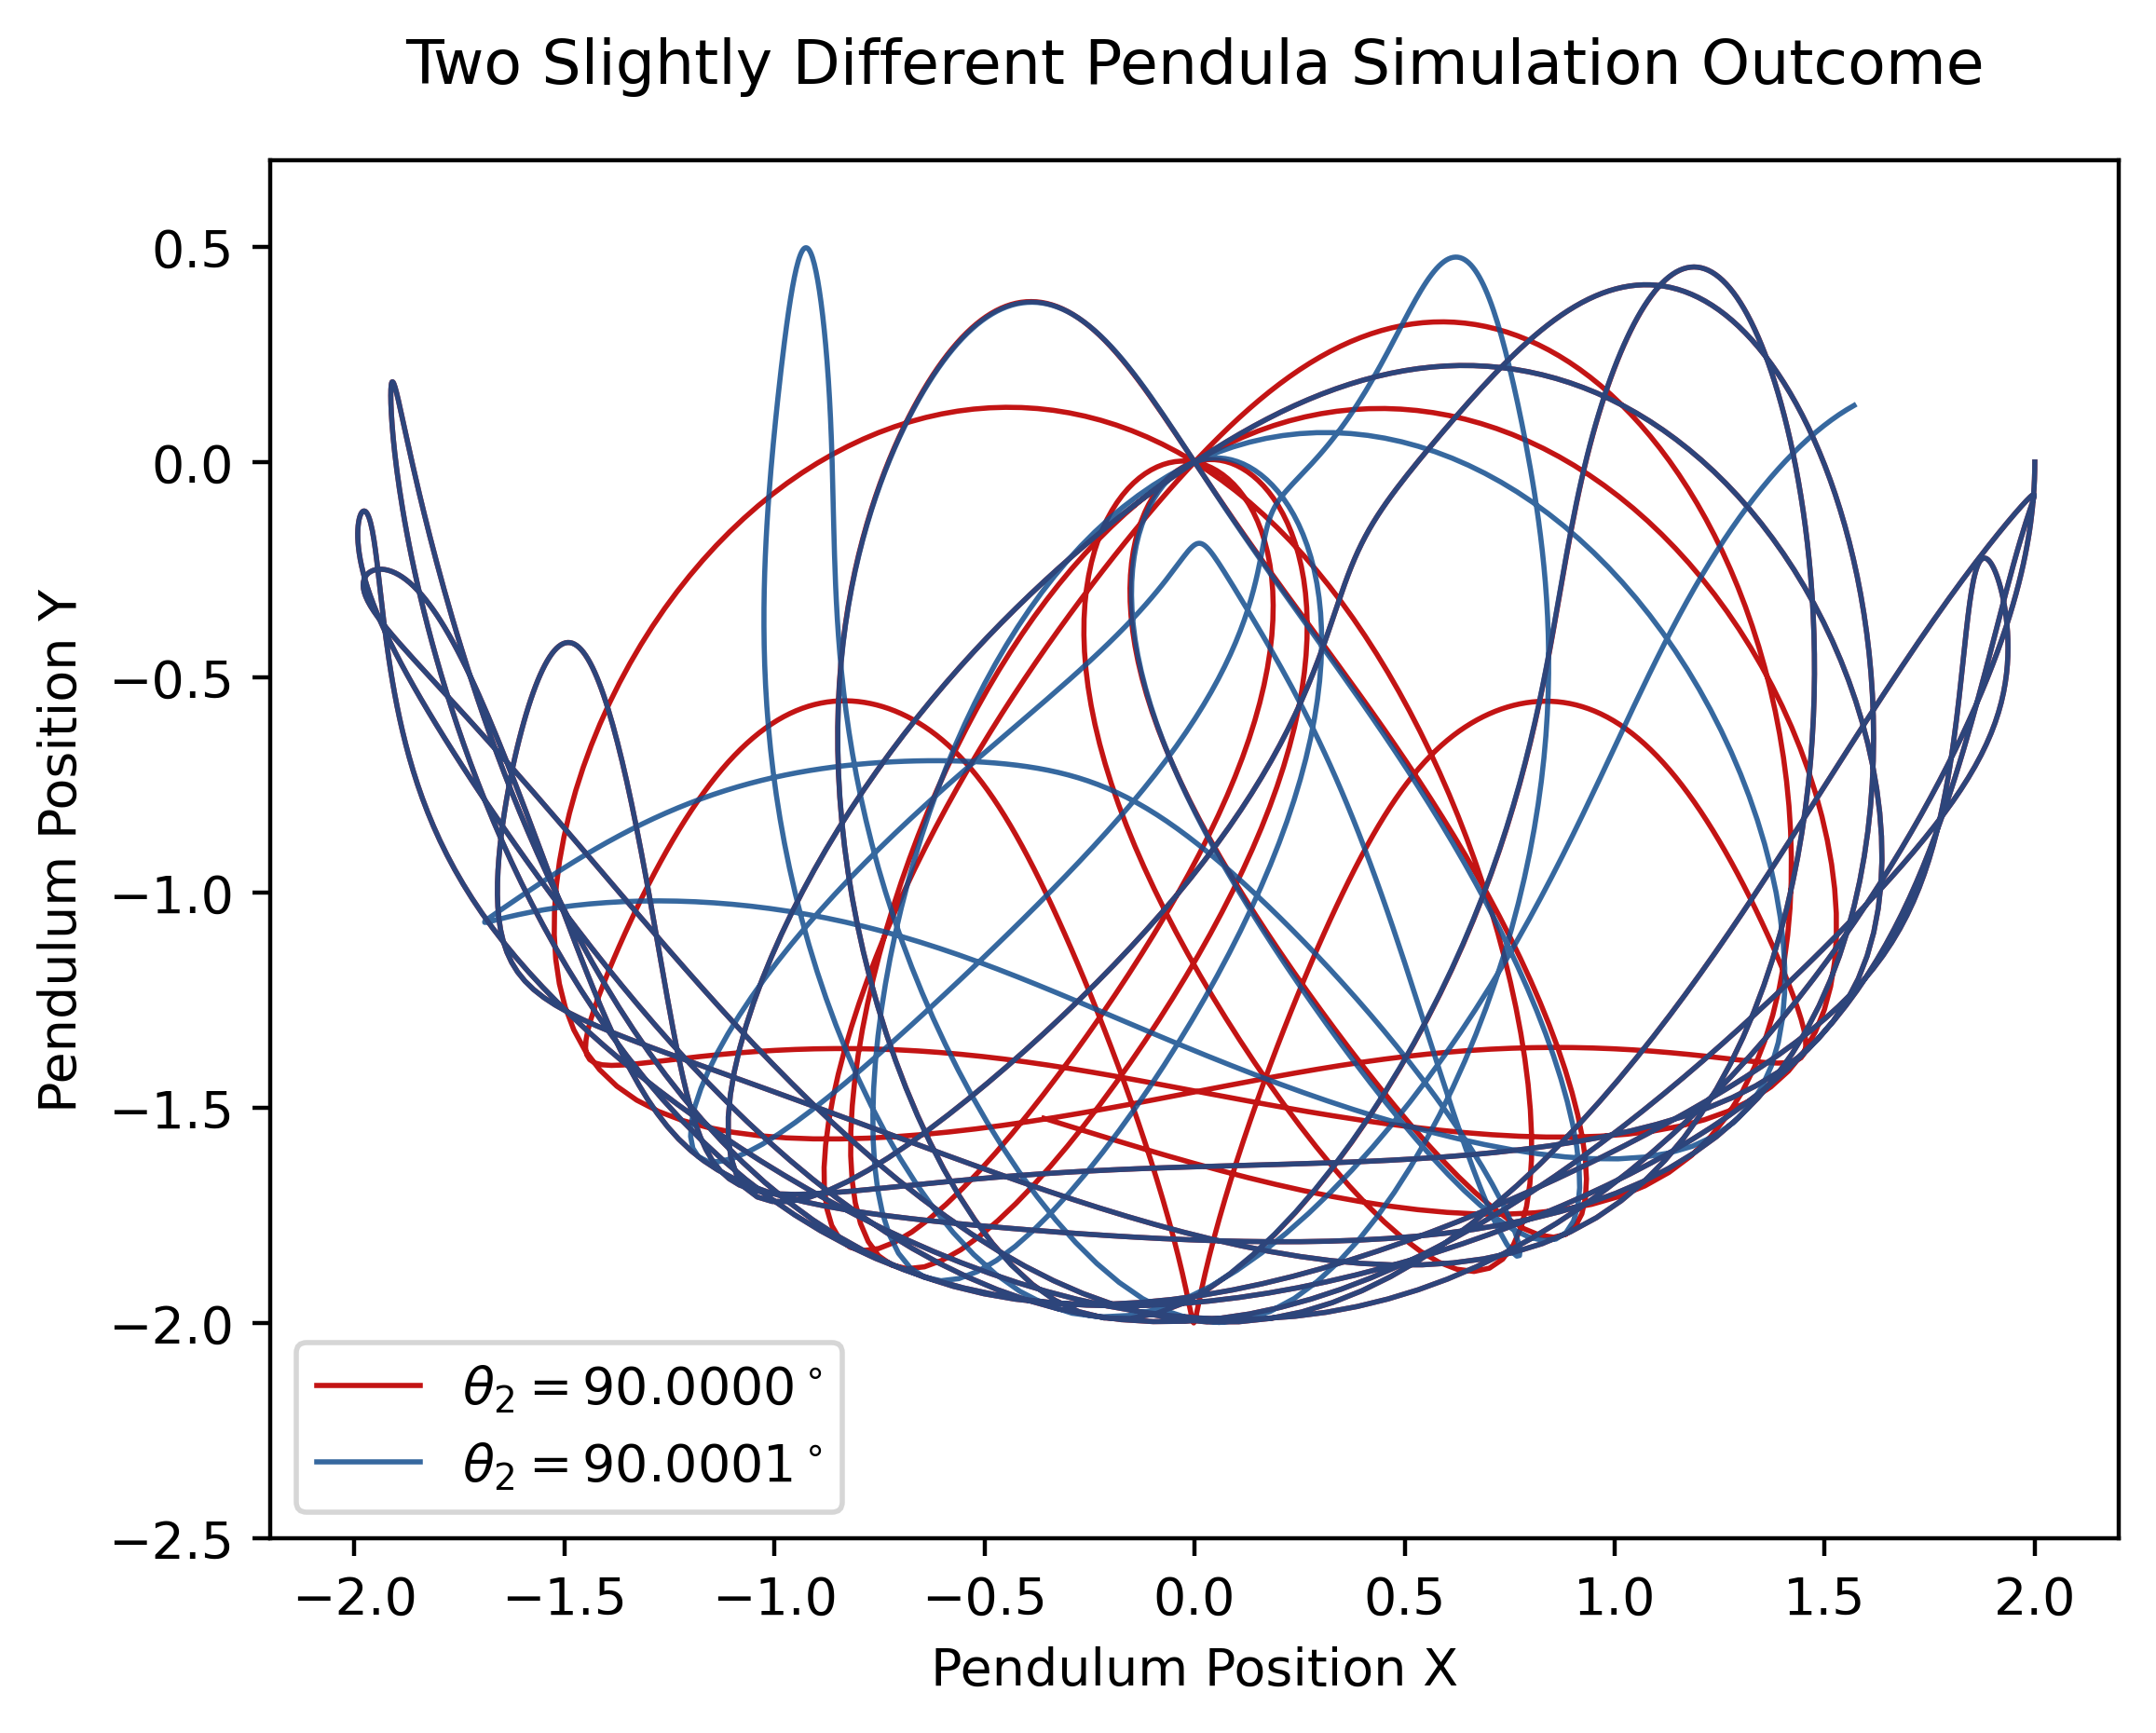

In [101]:
plt.figure(dpi = 400)
plt.title("Two Slightly Different Pendula Simulation Outcome", pad=15)
plt.ylabel("Pendulum Position Y")
plt.xlabel("Pendulum Position X")
plt.axis([-2.2, 2.2, -2.5, 0.7])
plt.plot(posx, posy,c= "#C00707", alpha=0.95, lw=1, label = r"$\theta_2=90.0000^\circ$")
#plt.plot(posx2, posy2, c="#FFB33F", alpha=0.75)
plt.plot(posx2, posy2, c="#134E8E", alpha=0.85,lw=1, label = r"$\theta_2=90.0001^\circ$")
#plt.plot(posx3, posy3, c="#134E8E", alpha=0.75)
plt.legend()
plt.savefig("Chaos_Intro.pdf", bbox_inches='tight')

In [55]:
from mpl_toolkits.mplot3d import Axes3D

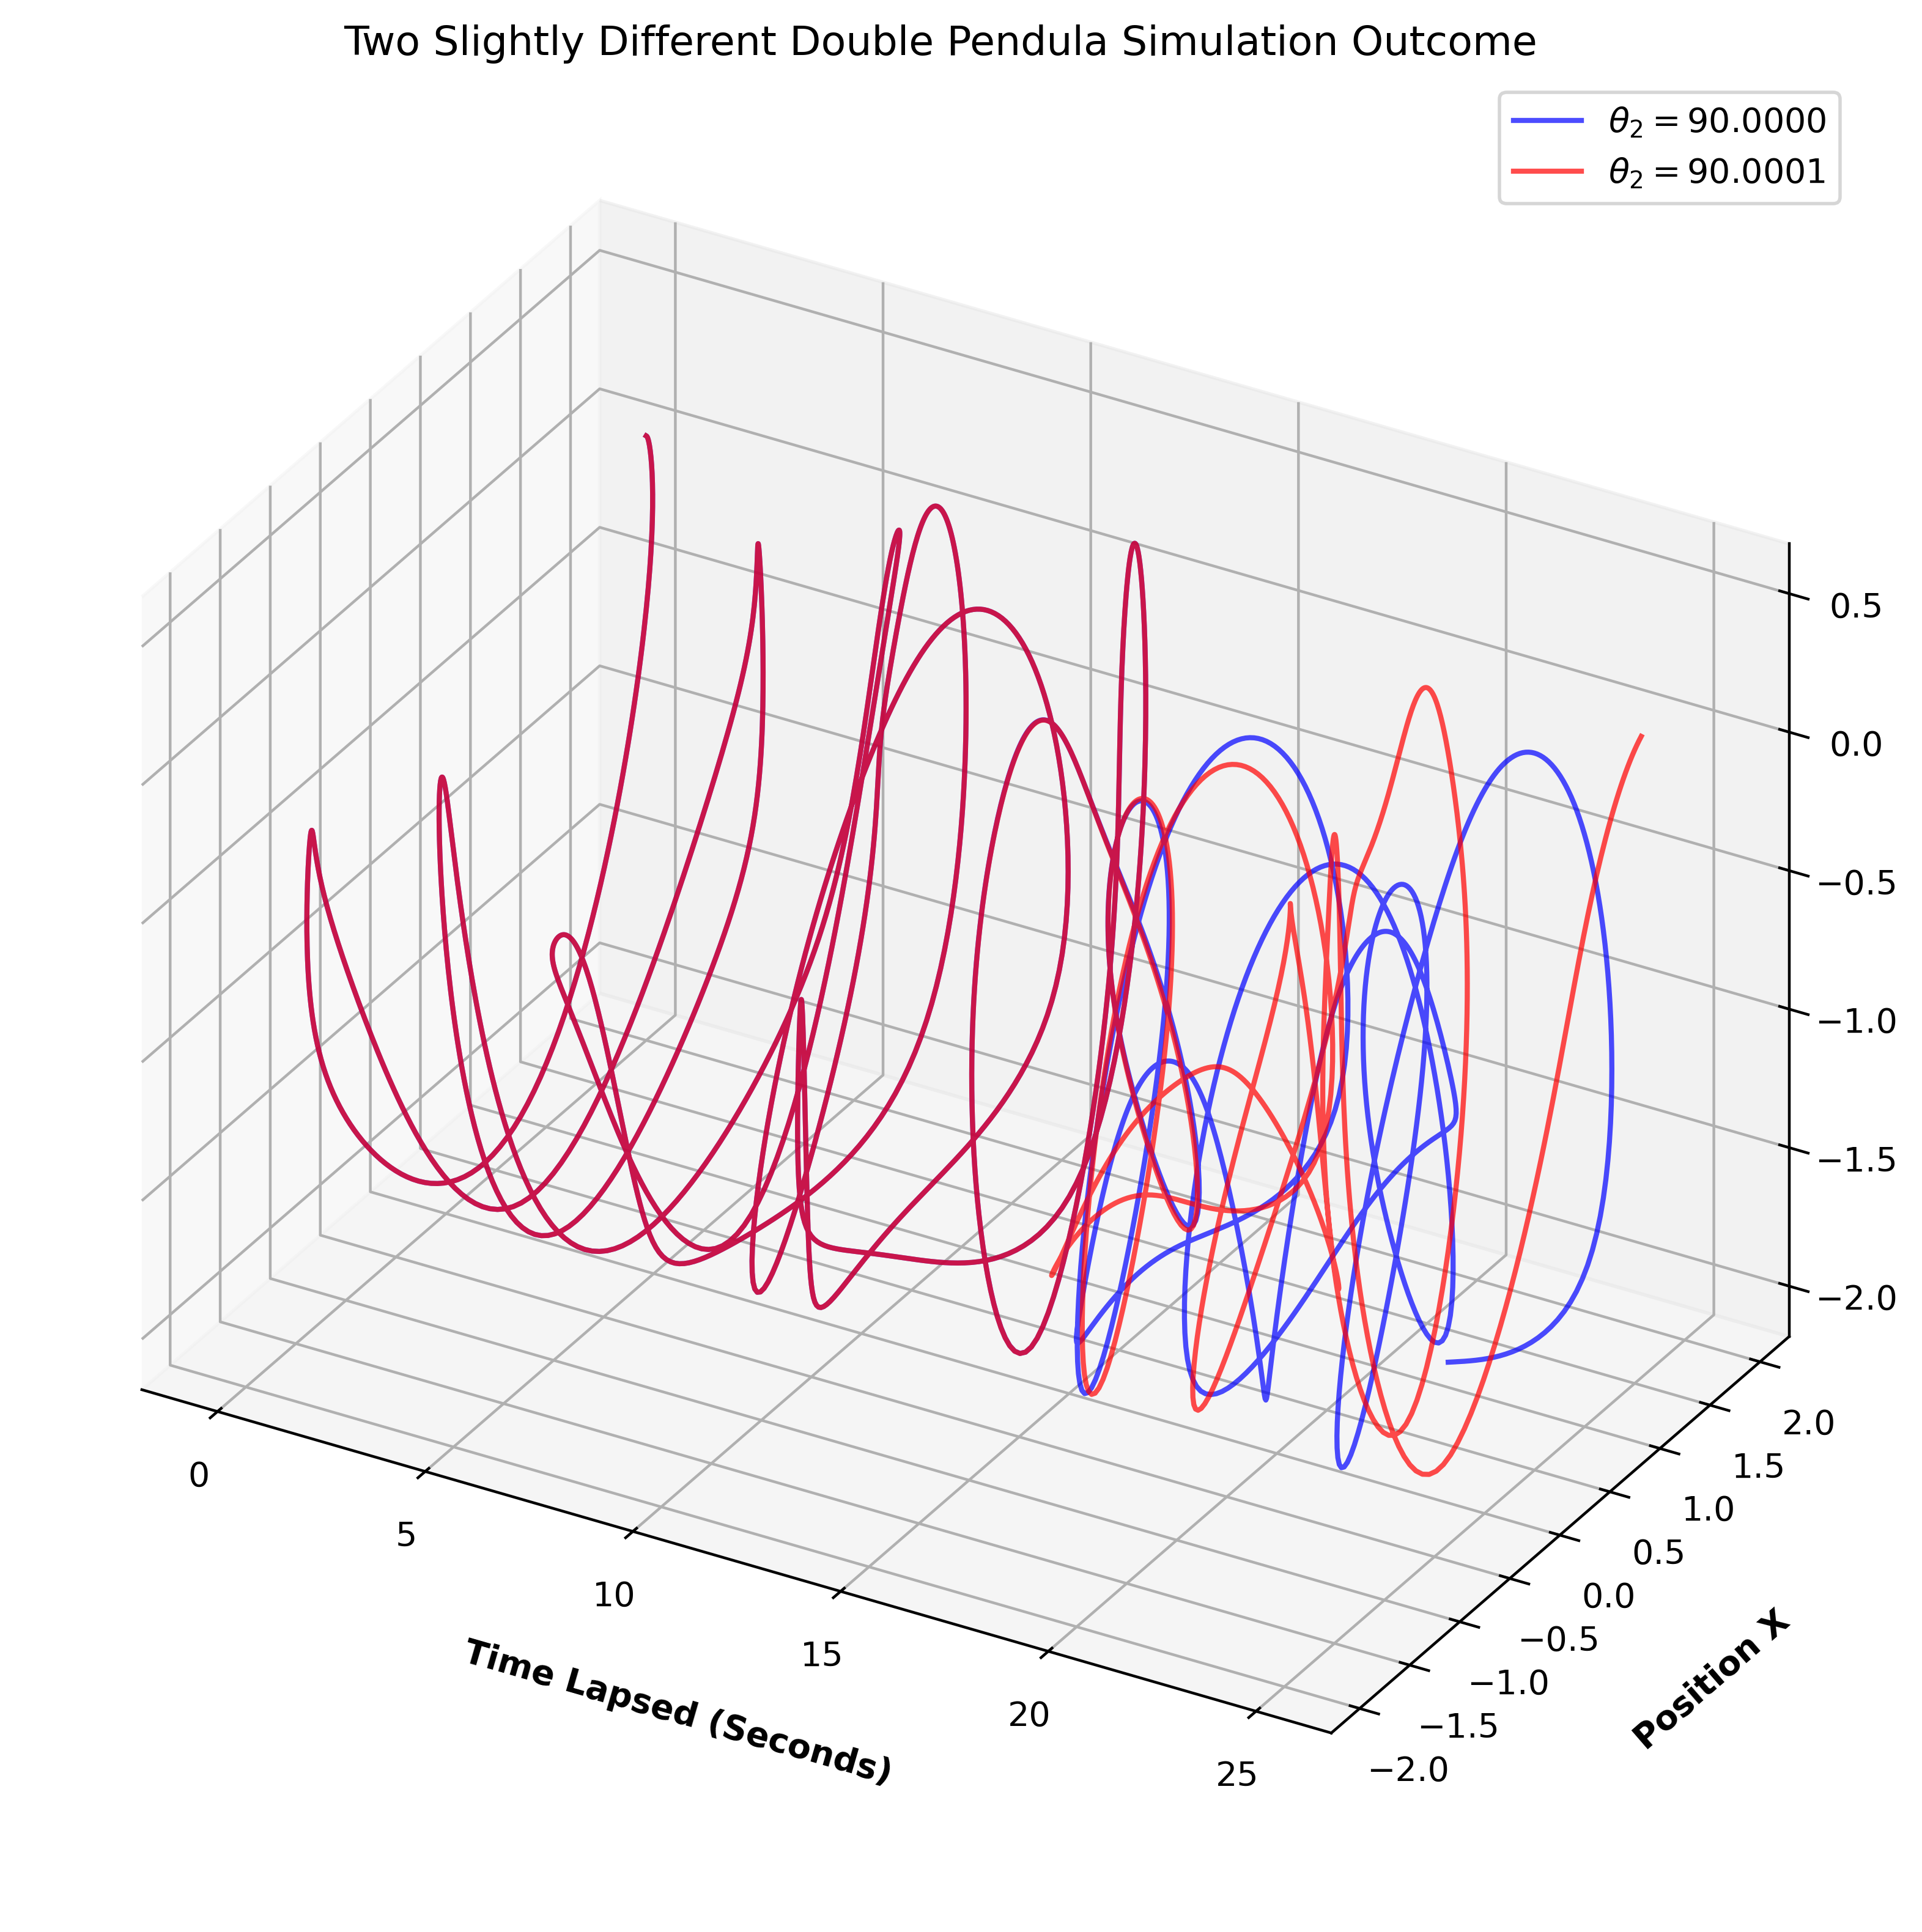

In [ ]:
fig = plt.figure(figsize=(8, 8), dpi=400) 
# 2. 将 3D 坐标系关联到这个指定的 fig 上
ax = plt.axes(projection='3d', proj_type='ortho')

ax.set_box_aspect((1.5, 1, 1))

ax.plot(time, posx, posy, color='blue', lw=1.5, alpha=0.7, label = r"$\theta_2=90.0000$")
#C00707
#FFB33F
ax.plot(time, posx2, posy2, color = 'red', lw=1.5, alpha=0.7, label = r"$\theta_2=90.0001$")
#ax.plot(time, posx3, posy3, color = '#134E8E', lw=1.5, alpha=0.7, label = r"$\theta_2=90.0002$")

plt.title("Two Slightly Different Double Pendula Simulation Outcome")

ax.set_xlabel("Time Lapsed (Seconds)", fontweight = "bold", labelpad=15)
ax.set_ylabel("Position X", fontweight = "bold", labelpad=15)
ax.set_zlabel("Position Y", fontweight = "bold", labelpad=15)

ax.legend()
ax.grid(alpha = 0.4, lw=1)
plt.tight_layout()
plt.subplots_adjust(right=1)
plt.savefig("new.png", dpi = 400, bbox_inches='tight')

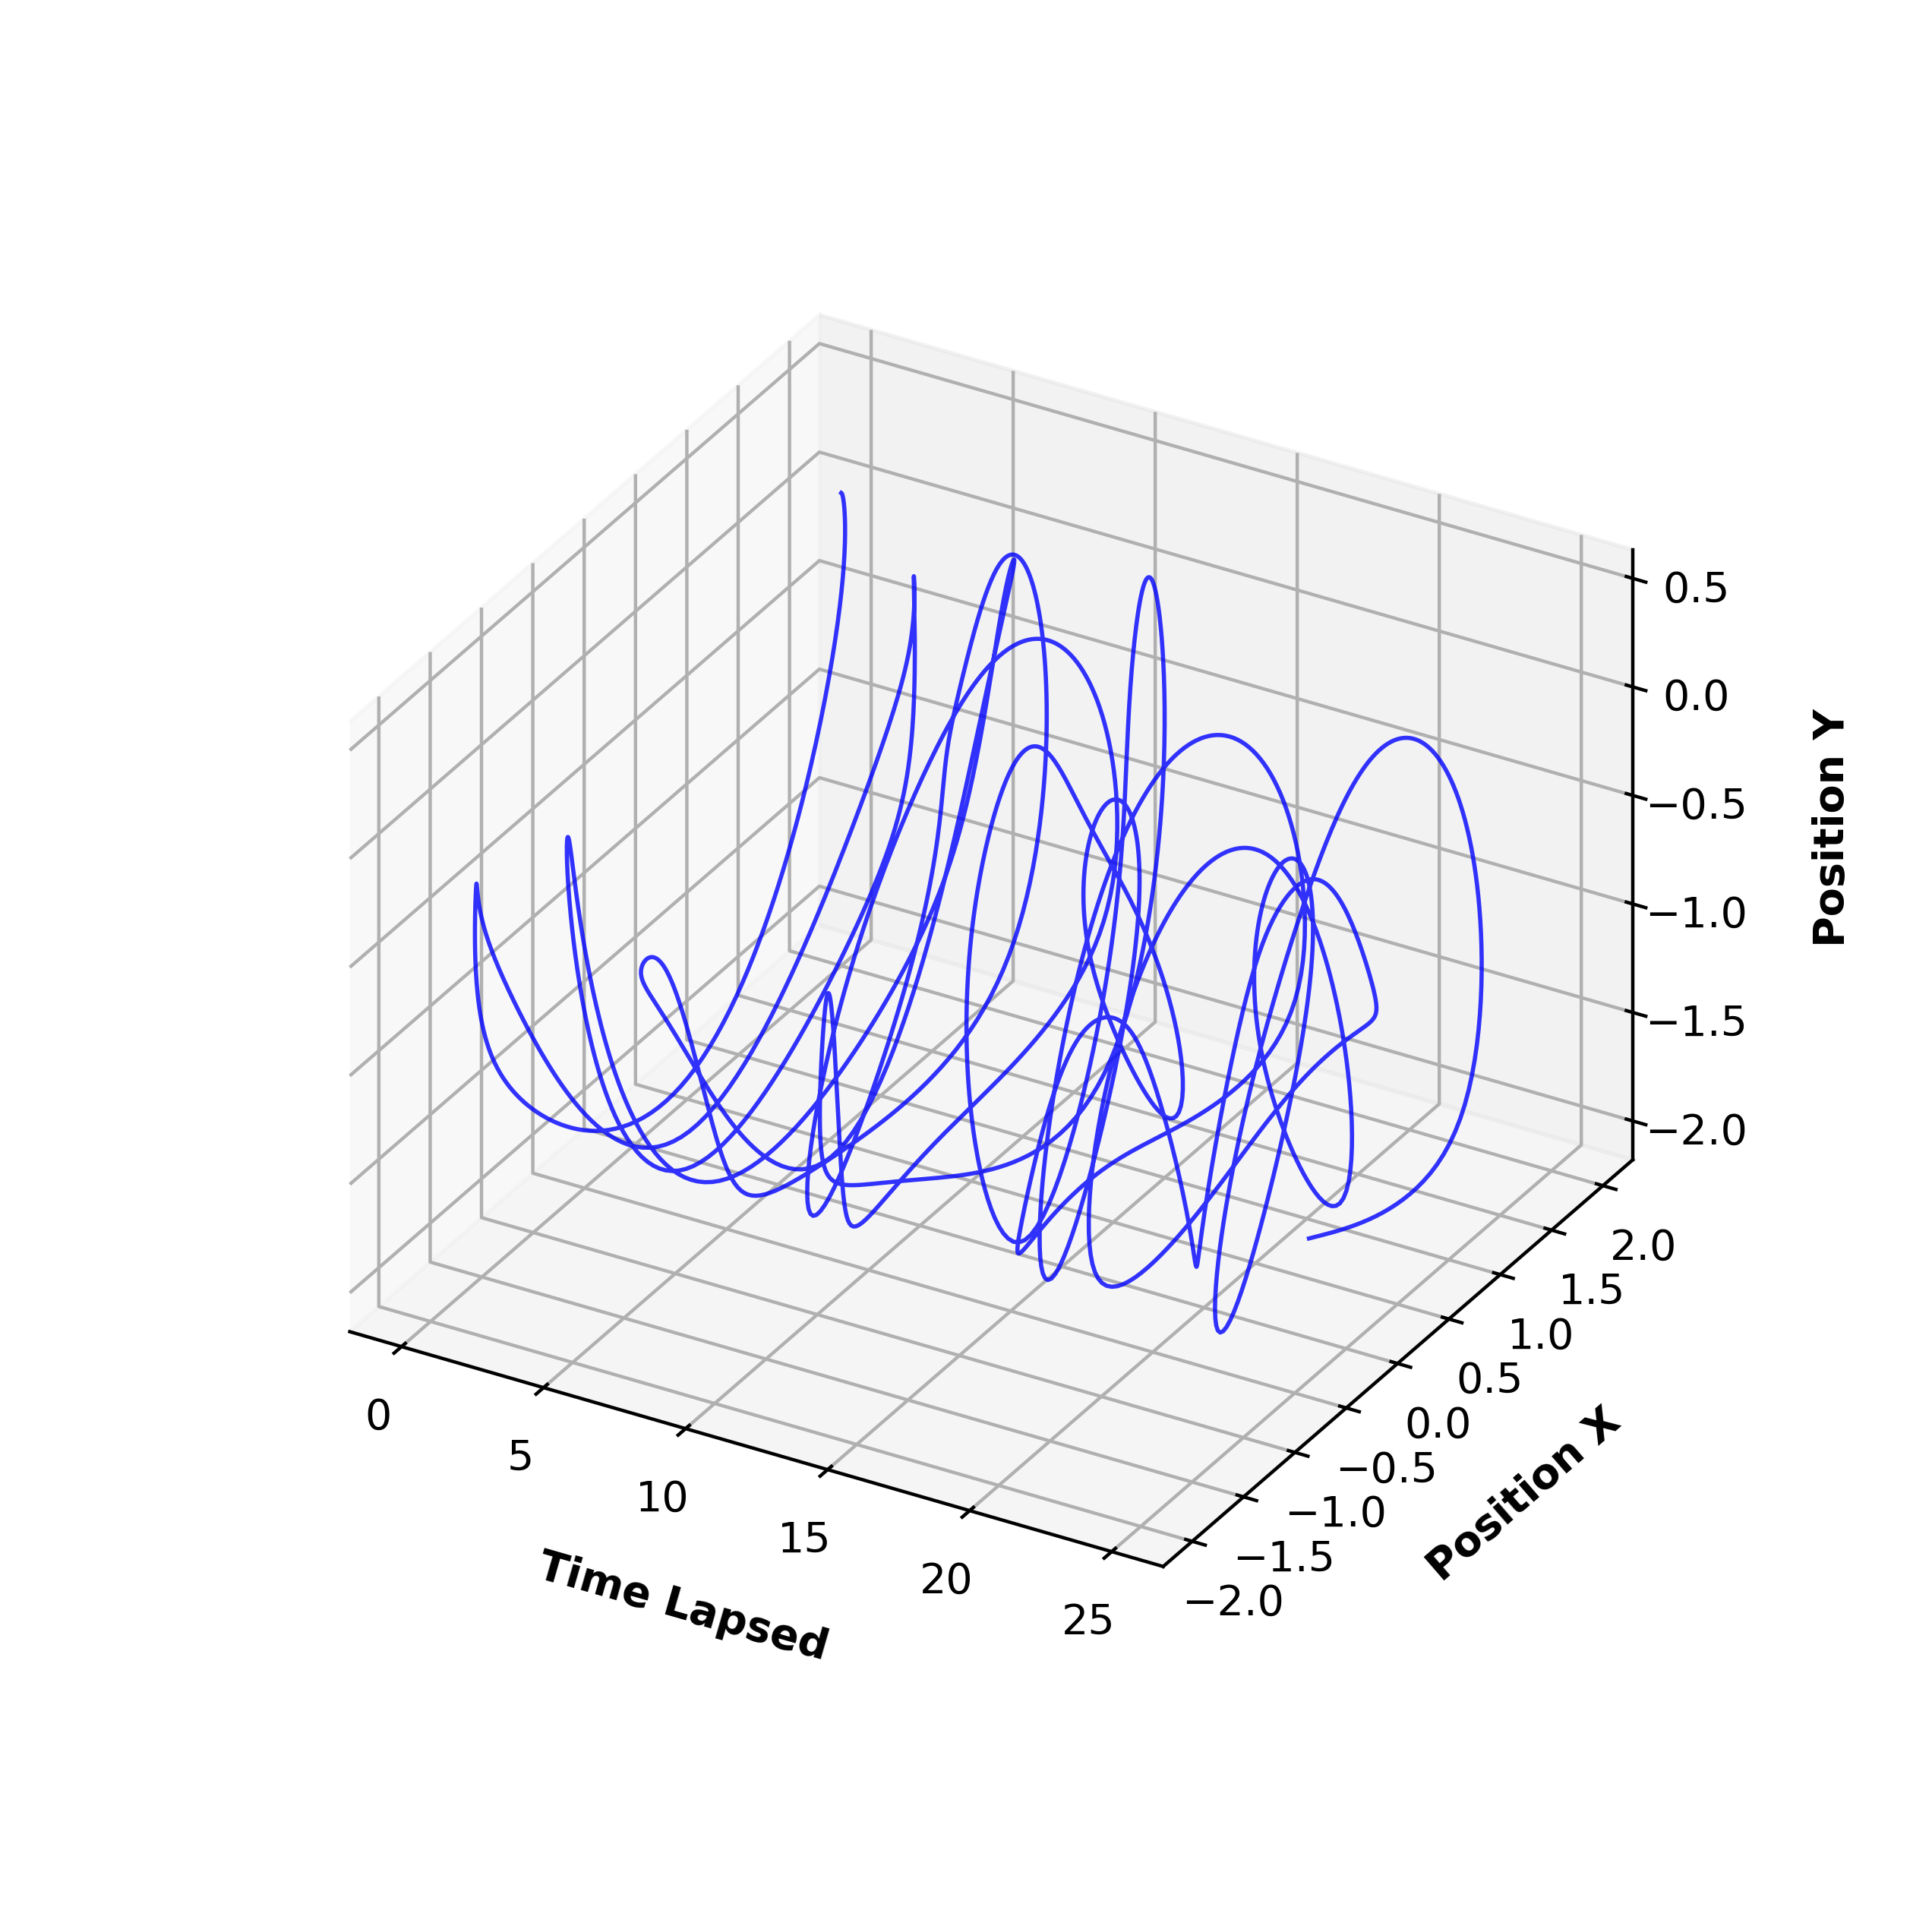

In [43]:
import matplotlib.pyplot as plt

# ================== 推荐写法（add_axes 手动控制位置） ==================
fig = plt.figure(figsize=(9, 8), dpi=400)   # 稍微加宽一点

# 手动定义 axes 位置: [左, 下, 宽, 高]  —— 关键是把宽度往左收，给右边留空间
ax = plt.axes(projection='3d', proj_type='ortho')

ax.set_box_aspect((1.5, 1, 1))

ax.plot3D(time, posx, posy, color='blue', lw=1, alpha=0.8)

ax.set_xlabel("Time Lapsed", fontweight="bold", labelpad=15)
ax.set_ylabel("Position X", fontweight="bold", labelpad=15)
ax.set_zlabel("Position Y", fontweight="bold", labelpad=15)

# 以下这些按顺序保留
ax.set_box_aspect(None, zoom=0.78)           # 非常重要
ax.zaxis.set_label_coords(1.22, 0.5)       # 如果还切，就把这行取消注释

plt.savefig('my_plot.png', 
            bbox_inches='tight', 
            pad_inches=0.5, 
            dpi=400)

In [23]:
import plotly.express as px

# 假设你有三个列表：time_list, x_list, y_list
fig = px.line_3d(x=time, y=posx, z=posy)
fig = px.line_3d(x=time, y=posx2, z=posy2)

# 顺便改一下轴标签（列表输入默认标签是 x, y, z）
fig.update_layout(scene=dict(
    xaxis_title='Time Lapsed',
    yaxis_title='Position X',
    zaxis_title='Position Y'
))

fig.show()